# Stage 1 — View 검출 (YOLOv11, AABB)

전체 도면에서 **view 영역**, **표제란 `title_block`**, **표·주기 블록 `notes`** 를 축정렬 박스로 검출합니다.

**워크플로**
1. `rasterize_pdf.ipynb` 로 만든 `data/drawings_pages/*.png` 50장을 **CVAT(rectangle)** 로 라벨링
2. CVAT → **"Ultralytics YOLO Detection"** 포맷으로 export → 압축 해제하여 `detection/view/cvat_export/` 에 둠
   (그 안에 `images/`, `labels/` 존재). **이미 `datasets/view/{train,val}` 가 채워져 있으면 split 셀은 자동 건너뜀.**
3. 아래 split 셀로 `datasets/view/{train,val}` 구성 (90/10, seed 42)
4. 학습 → 검증 → 추론·크롭

- 커널: **kardi_env** (ultralytics 8.4.67)
- 클래스: `detection/view/view.yaml` 참고 (0=view, 1=title_block, 2=notes)

> **🔹 역할** — 환경 확인(ultralytics·torch·CUDA) 및 실행 위치 검증

In [1]:
# ── 환경 확인 ─────────────────────────────────────────────────────
from pathlib import Path
import ultralytics, torch
from ultralytics import YOLO
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__,
      "| cuda", torch.cuda.is_available())
HERE = Path.cwd()
assert (HERE / "view.yaml").exists(), f"detection/view 에서 실행하세요 (현재: {HERE})"

ultralytics 8.4.67 | torch 2.11.0+cu130 | cuda True


> **🔹 역할** — CVAT export → train/val 분리(stem 매칭, 9:1)

In [3]:
# ── CVAT export → train/val 분리 ─────────────────────────────────
# CVAT 'Ultralytics YOLO Detection' export 압축을 풀어 cvat_export/ 에 두세요.
# (images/, labels/ 폴더 포함). 이미지-라벨 stem 매칭만 사용합니다.
# ※ 이미 datasets/view/{train,val} 가 채워져 있고 cvat_export 가 없으면 이 셀은 건너뜁니다.
import random, shutil
EXPORT_DIR = Path("cvat_export")
DST        = Path("datasets/view")
VAL_RATIO, SEED = 0.1, 42

src_img = EXPORT_DIR / "images"
src_lbl = EXPORT_DIR / "labels"

already = sorted((DST / "images" / "train").glob("*.*")) if (DST / "images" / "train").exists() else []
if not src_img.exists():
    # cvat_export 가 없으면: 기존 split 을 그대로 사용 (덮어쓰기 방지)
    assert already, f"{src_img} 도 없고 {DST}/images/train 도 비어있음 — CVAT export 를 두거나 데이터를 배치하세요"
    n_val = len(list((DST / "images" / "val").glob("*.*")))
    print(f"cvat_export 없음 → 기존 split 사용: train {len(already)} / val {n_val}")
else:
    stems = sorted(p.stem for p in src_img.glob("*.*")
                   if (src_lbl / (p.stem + ".txt")).exists())
    random.Random(SEED).shuffle(stems)
    n_val = max(1, int(len(stems) * VAL_RATIO))
    splits = {"val": stems[:n_val], "train": stems[n_val:]}
    for split, names in splits.items():
        for sub in ("images", "labels"):
            (DST / sub / split).mkdir(parents=True, exist_ok=True)
        for st in names:
            img = next(src_img.glob(st + ".*"))
            shutil.copy(img, DST / "images" / split / img.name)
            shutil.copy(src_lbl / (st + ".txt"), DST / "labels" / split / (st + ".txt"))
    print({k: len(v) for k, v in splits.items()})

cvat_export 없음 → 기존 split 사용: train 87 / val 22


> **🔹 역할** — YOLOv11n view 탐지기 학습(AABB, 도면 특화 보수적 증강)

In [4]:
# ── 학습 (YOLOv11n, 도면 특화 보수적 증강) ────────────────────────
# 도면은 방향이 고정 → 좌우/상하 반전·회전·모자이크 OFF, 밝기만 약하게.
# 데이터 ~87장 소규모 → batch=8, patience=50(과적합 전 조기종료).
model = YOLO("yolo11n.pt")          # 사전학습 시드 (자동 다운로드)
model.train(
    data="view.yaml", epochs=200, imgsz=1280, batch=8, patience=50,
    project="runs", name="view", exist_ok=True, seed=42,
    fliplr=0.0, flipud=0.0, degrees=0.0, mosaic=0.0,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, translate=0.05, scale=0.2,
)

New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.67 🚀 Python-3.10.19 torch-2.11.0+cu130 CUDA:0 (NVIDIA GB10, 124611MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=view.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=view, nbs=64, nms=F

/home/jhkim/anaconda3/envs/kardi_env/lib/python3.10/site-packages/polars/meta/build.py:5: UserWarning: Polars binary is missing!
  from polars._utils.polars_version import get_polars_version


Plotting labels to /home/jhkim/projects/donut_vml/yolo_finetune_donut_pipeline/detection/view/runs/detect/runs/view/labels.jpg... 
WARNING ⚠️ name 'PySeries' is not defined
Image sizes 1280 train, 1280 val
Using 8 dataloader workers
Logging results to /home/jhkim/projects/donut_vml/yolo_finetune_donut_pipeline/detection/view/runs/detect/runs/view
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      4.47G      2.838      5.739       3.14         24       1280: 100% ━━━━━━━━━━━━ 11/11 3.1s/it 34.3s1.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8s/it 3.5s<10.9s
                   all         22         82    0.00239      0.296     0.0151    0.00572

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      5.65G       1.03        3.8      1.546         27       1280: 100% ━━━━━━━━━━━━ 11/11 1.2it/s 9.1s0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0xf49d444e4580>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

> **🔹 역할** — 학습 모델 검증(mAP50/mAP50-95)

In [6]:
# ── 검증 (mAP) ────────────────────────────────────────────────────
# ※ ultralytics 8.4.67 은 detect task 를 runs/detect/runs/view/ 에 중첩 저장함 (args.yaml 의 save_dir 참고).
#   학습 셀의 project="runs" 가 runs_dir/{task} 아래로 들어가서 생긴 경로.
BEST = "runs/detect/runs/view/weights/best.pt"
best = YOLO(BEST)
metrics = best.val(data="view.yaml")
print(f"mAP50 = {metrics.box.map50:.3f} | mAP50-95 = {metrics.box.map:.3f}")

Ultralytics 8.4.67 🚀 Python-3.10.19 torch-2.11.0+cu130 CUDA:0 (NVIDIA GB10, 124611MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4300.1±574.4 MB/s, size: 441.7 KB)
val: Scanning /home/jhkim/projects/donut_vml/yolo_finetune_donut_pipeline/detection/view/datasets/view/labels/val.cache... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 6.2s/it 12.4s27.0s
                   all         22         82      0.984      0.986      0.994      0.929
                  view         22         53      0.981      0.985      0.993       0.87
           title_block         22         22          1      0.973      0.995      0.995
                 notes          7          7      0.972          1      0.995      0.923
Speed: 204.6ms preprocess, 35.3ms inference, 0.0ms loss, 0.6

> **🔹 역할** — 추론 → view 영역 크롭 저장(Stage 2 입력 생성)

In [7]:
# ── 추론 → view 크롭 저장 (Stage 2 입력) ──────────────────────────
import sys; sys.path.append("..")          # detection/ 의 crop_utils 사용
from crop_utils import save_crops_from_result
BEST  = "runs/detect/runs/view/weights/best.pt"   # 실제 저장 경로 (중첩)
best  = YOLO(BEST)
PAGES = Path("../../../data/drawings_pages")
OUT   = Path("../../../data/view_crops")
n = 0
for img in sorted(PAGES.glob("*.png")):
    r = best.predict(img, imgsz=1280, conf=0.25, verbose=False)[0]
    n += len(save_crops_from_result(r, OUT, img.stem, pad=4))
print(f"view 크롭 {n}개 → {OUT}")

view 크롭 197개 → ../../../data/view_crops


> **🔹 역할** — 예측 박스 시각화(육안 검증)

/home/jhkim/anaconda3/envs/kardi_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jhkim/anaconda3/envs/kardi_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


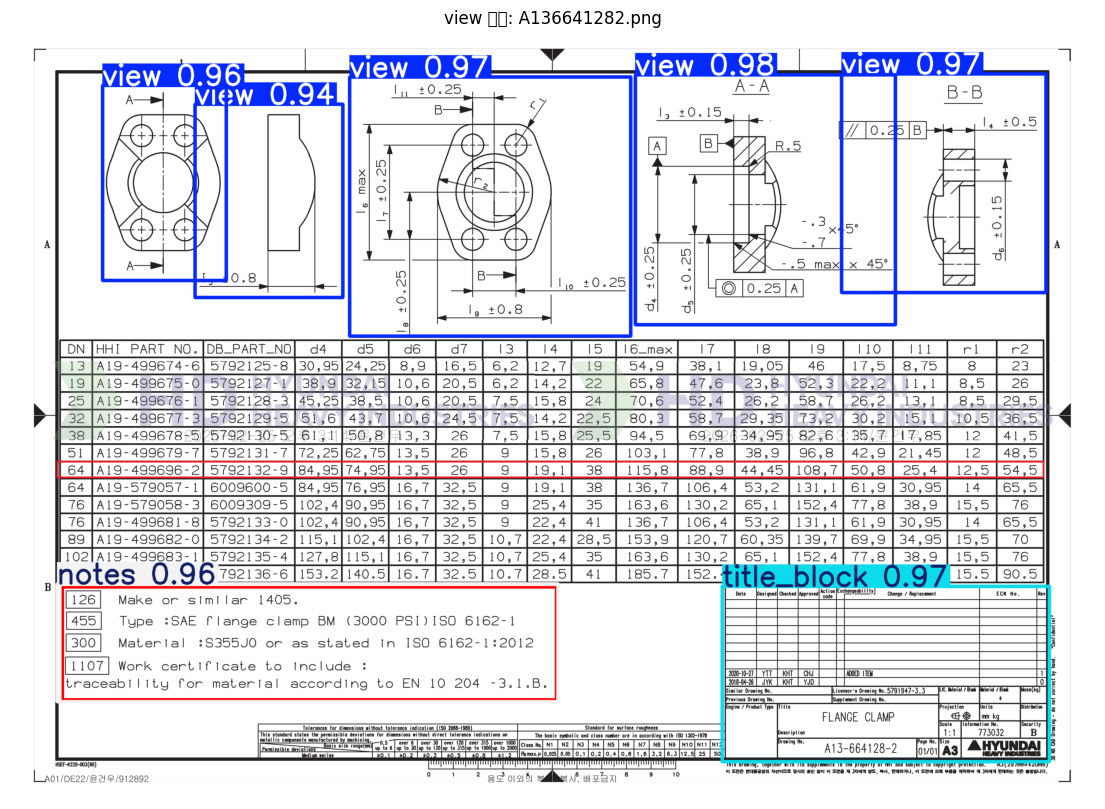

In [10]:
# ── 예측 박스 시각화(육안 검증) ───────────────────────────────────
# VS Code Jupyter 에서 figure 가 텍스트(<Figure ...>)로만 남고 inline 이미지가 안 뜨면
# matplotlib 백엔드가 inline 으로 안 잡힌 것 → 아래 매직으로 강제.
%matplotlib inline
import matplotlib.pyplot as plt
BEST = "runs/detect/runs/view/weights/best.pt"    # 실제 저장 경로 (중첩)
sample = sorted(Path("../../../data/drawings_pages").glob("*.png"))[0]
r = YOLO(BEST).predict(sample, imgsz=1280, conf=0.25, verbose=False)[0]
fig = plt.figure(figsize=(14, 10))
plt.imshow(r.plot()[..., ::-1])   # r.plot() 은 BGR → RGB 로 뒤집어 표시
plt.axis("off")
plt.title(f"view 예측: {sample.name}")
plt.show()
plt.close(fig)